# Bin-integrated response functions $\mathcal{R}_{\left[E_i^\prime, E_{i+1}^\prime\right]}(E_\nu)$

Plots the bin-integrated response functions exported by
`{1eV,5eV}/src/05b_curlyR_export.wl` (2000 $E_\nu$ points, units
cm$^2$/(MeV kg)) from `{1eV,5eV}/output/curlyR_table.csv`.

Style follows `plot_band_comparison` (physrev style sheet, log $E_\nu$ axis,
large labels, frameless legend); each curve is labelled by its measured-energy $E'$
bin. Run this notebook from the `Mathematica/` folder.


In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

# physrev style sheet used by plot_band_comparison
_style = os.path.join('..', '1eV', 'physrev.mplstyle')
if os.path.exists(_style):
    plt.style.use(_style)

NORM = 1e-16   # y axis in units of 1e-16 cm^2/(MeV kg)

# Okabe–Ito palette (colorblind-safe)
COLORS = [
    '#000000',  # black
    '#0072B2',  # blue
    '#D55E00',  # vermillion
    '#009E73',  # bluish green
    '#CC79A7',  # reddish purple
    '#E69F00',  # orange
    '#56B4E9',  # sky blue
]

LINESTYLES = [
    'solid', 'dashed', 'dotted', 'dashdot',
    (0, (5, 1)),            # densely dashed
    (0, (1, 1)),            # densely dotted
    (0, (3, 1, 1, 1)),     # densely dashdotted
    (0, (3, 1, 1, 1, 1, 1)),  # densely dashdotdotted
]

def _style_cycle(n):
    """Return (color, linestyle) pairs cycling linestyle first, then color."""
    styles = []
    for i in range(n):
        ls = LINESTYLES[i % len(LINESTYLES)]
        c  = COLORS[i // len(LINESTYLES) % len(COLORS)]
        styles.append((c, ls))
    return styles

def plot_curlyR(thr, xmin):
    df = pd.read_csv(os.path.join(thr, 'output', 'curlyR_table.csv'))
    ev = df['Ev_MeV'].values
    bins = [c for c in df.columns if c != 'Ev_MeV']
    styles = _style_cycle(len(bins))

    plt.figure(figsize=(8, 6))
    for (c, ls), col in zip(styles, bins):
        plt.plot(ev, df[col].values / NORM, color=c, ls=ls, lw=1.4,
                 label=col.replace('-', '–'))

    plt.xscale('log')
    plt.xlim(xmin, 10)
    plt.ylim(0, None)
    plt.xlabel(r"$E_\nu$ [MeV]", fontsize=30)
    plt.ylabel(r"$\mathcal{R}$ [$10^{-16}$ cm$^2$/(MeV kg)]", fontsize=22)
    plt.gca().xaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))
    plt.tick_params(axis='both', which='major', labelsize=23)
    plt.tick_params(axis='both', which='minor', labelsize=23)
    # DejaVu for the legend: the physrev font (cmr10) has no en-dash glyph
    plt.legend(loc='upper left', frameon=False, ncol=3,
               prop={'family': 'DejaVu Sans', 'size': 12.0},
               title=r"$E'$ bin", title_fontsize=20)
    plt.title(rf"$E'_{{\rm thr}} = {thr[0]}\,$eV", fontsize=20)
    plt.tight_layout()
    out = os.path.join(thr, 'output', 'curlyR_matplotlib.pdf')
    plt.savefig(out, bbox_inches='tight')
    print('saved', out)
    plt.show()

saved 1eV/output/curlyR_matplotlib.pdf


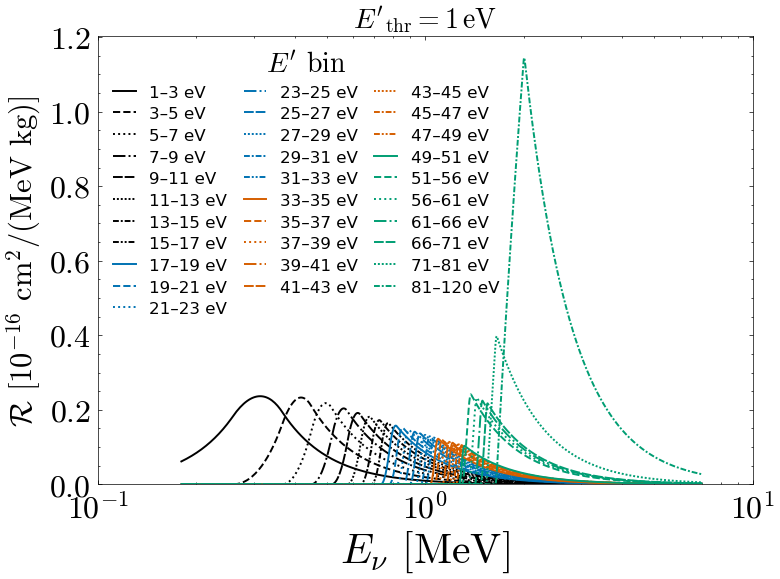

In [37]:
plot_curlyR('1eV', 0.1)

saved 5eV/output/curlyR_matplotlib.pdf


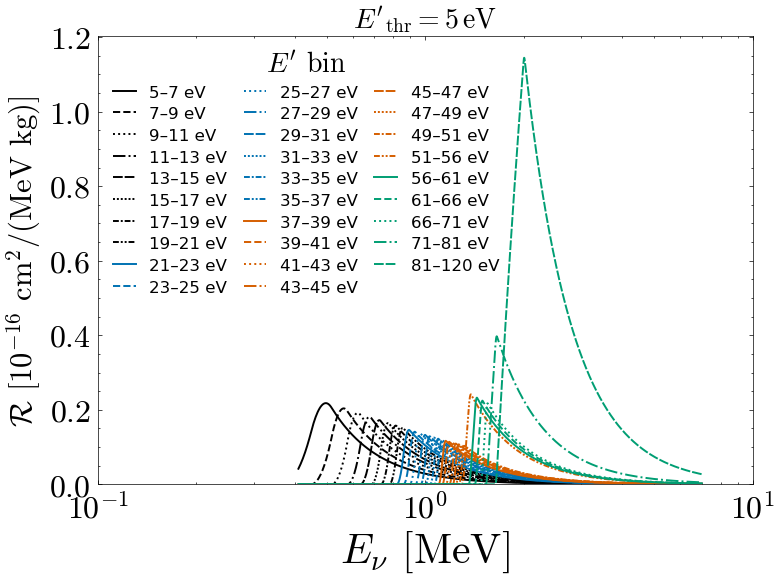

In [38]:
plot_curlyR('5eV', 0.1)